# Caregiver Timesheet Review-Risk Prediction

**Goal:** predict whether a home-care visit timesheet is likely to need *manual review*
before payroll/billing processing, using visit-level signals (duration match, signature
presence, task completion, GPS mismatch, etc.).

This project is inspired by a real operational problem in home-care agencies: caregivers
submit timesheets after each visit, and a portion of them fail automatic verification and
require a staff member to review them by hand.

> **Data note:** No real company or patient data is used. The dataset below is
> synthetically generated (`generate_data.py`) to reflect realistic relationships between
> visit features and review outcomes, based on publicly-understood home-care operations.

## 1. Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/caregiver_timesheets.csv")
df.head()

   caregiver_id  caregiver_tenure_months  scheduled_duration_min  actual_duration_min  duration_deviation_min  arrival_deviation_min  tasks_assigned  tasks_completed  task_completion_rate  has_signature entry_method  gps_mismatch_km  day_of_week  is_weekend  needs_manual_review
0            11                       37                      60                 62.0                     2.0                   10.0               2                1                 0.500              1   mobile_app             1.16            6           1                    0
1            93                       49                      30                 24.0                    -6.0                   -4.0               3                2                 0.667              1   mobile_app             0.48            0           0                    1
2            79                       38                      60                 57.0                    -3.0                   -5.0               4               

In [2]:
df.shape

(6000, 15)

## 2. Target distribution

What share of timesheets need manual review?

In [3]:
df['needs_manual_review'].value_counts(normalize=True)

needs_manual_review
0    0.65
1    0.35

About **35.0%** of visits are flagged for manual review — in line with the ~35% manual-review rate observed operationally before process improvements.

## 3. Exploratory analysis

How does review risk relate to key features?

In [4]:
df.groupby('needs_manual_review')[['task_completion_rate', 'has_signature', 'gps_mismatch_km']].mean()

                     task_completion_rate  has_signature  gps_mismatch_km
needs_manual_review                                                      
0                                   0.744          0.994            0.358
1                                   0.612          0.873            0.346

Visits that get flagged have noticeably lower task-completion rates, are less likely to have a signature on file, and show larger GPS location mismatches — consistent with what a verification team would expect.

## 4. Feature engineering & train/test split

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "caregiver_tenure_months", "scheduled_duration_min", "duration_deviation_min",
    "arrival_deviation_min", "tasks_assigned", "task_completion_rate",
    "has_signature", "gps_mismatch_km", "is_weekend",
]
df["entry_method_paper"] = (df["entry_method"] == "paper").astype(int)
feature_cols.append("entry_method_paper")

X = df[feature_cols]
y = df["needs_manual_review"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
X_train.shape, X_test.shape

((4500, 10), (1500, 10))

## 5. Model 1 — Logistic Regression

Chosen as the production model for its transparency: coefficients can be inspected and even re-implemented outside Python (e.g. in the dashboard app).

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)
pred = logreg.predict(X_test_s)
proba = logreg.predict_proba(X_test_s)[:, 1]

{
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "roc_auc": roc_auc_score(y_test, proba),
}

{
  "accuracy": 0.7466666666666667,
  "precision": 0.6579520697167756,
  "recall": 0.5752380952380952,
  "f1": 0.6138211382113821,
  "roc_auc": 0.8353465201465202
}

## 6. Model 2 — Random Forest

A more flexible model used as a benchmark for the achievable ceiling in predictive performance.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

{
    "accuracy": accuracy_score(y_test, pred_rf),
    "precision": precision_score(y_test, pred_rf),
    "recall": recall_score(y_test, pred_rf),
    "f1": f1_score(y_test, pred_rf),
    "roc_auc": roc_auc_score(y_test, proba_rf),
}

{
  "accuracy": 0.7913333333333333,
  "precision": 0.7442396313364056,
  "recall": 0.6152380952380953,
  "f1": 0.6736183524504692,
  "roc_auc": 0.8760166056166057
}

Random Forest reaches a higher ROC-AUC (0.876 vs 0.835) — expected, since it can capture non-linear interactions. In production we'd trade a small amount of accuracy for the interpretability of Logistic Regression, which is what powers the interactive dashboard in this repo.

## 7. Feature importance (Random Forest)

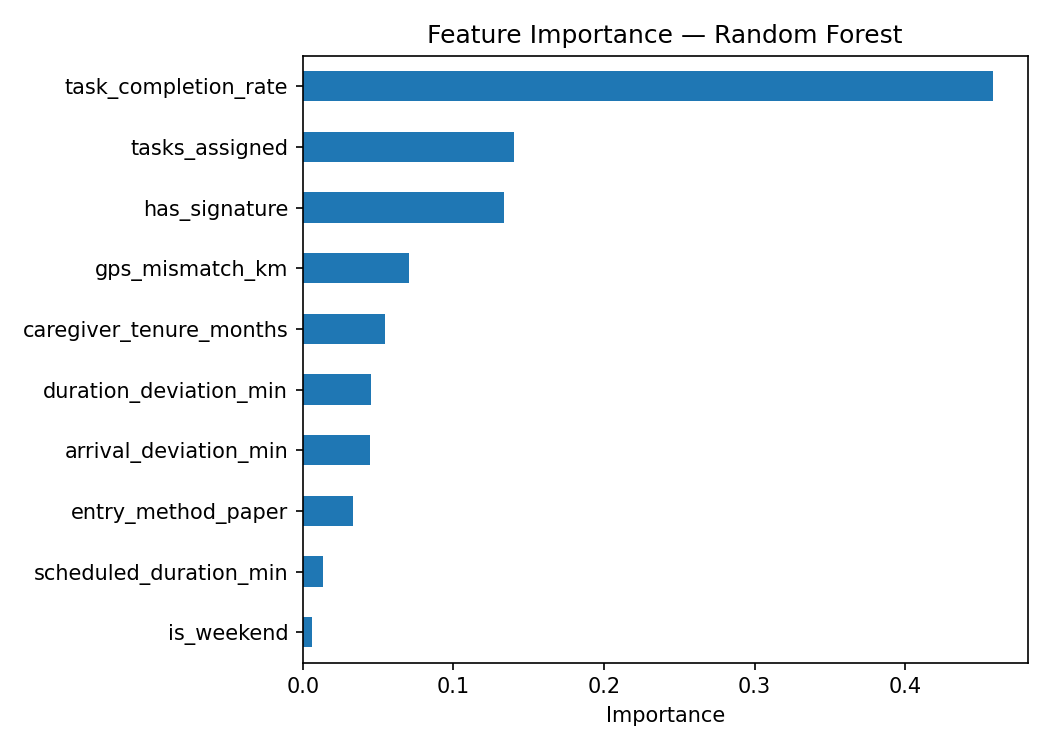

In [8]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(7,5))
plt.gca().invert_yaxis()
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Task completion rate**, **tasks assigned**, and **missing signature** are by far the strongest predictors — matching the intuition that incomplete documentation drives most manual-review flags.

## 8. ROC curve comparison

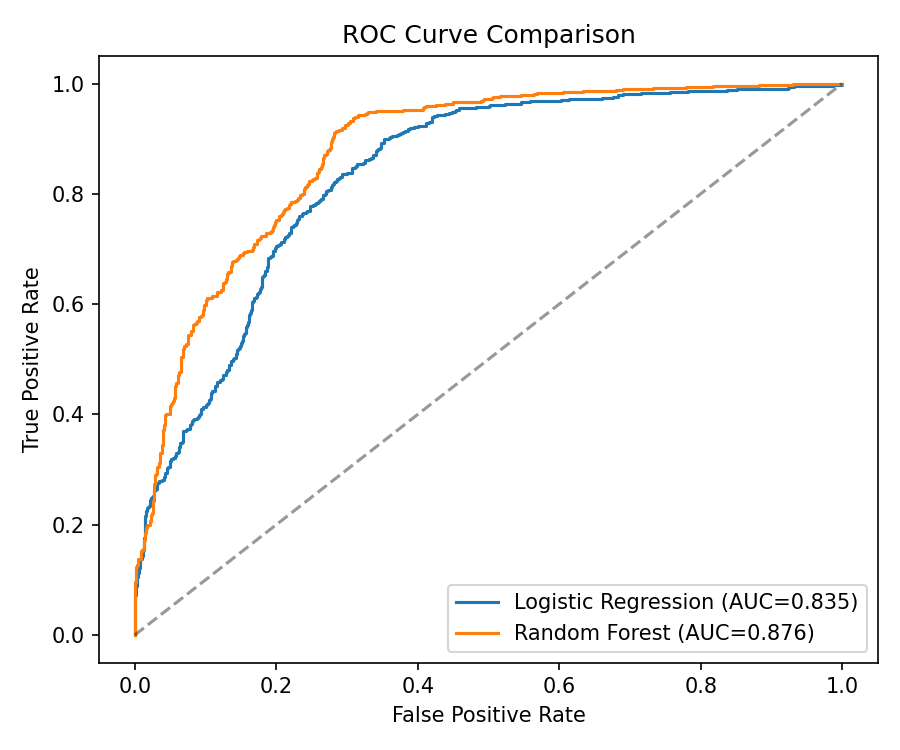

In [9]:
from sklearn.metrics import roc_curve

for name, proba_ in [('Logistic Regression', proba), ('Random Forest', proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba_)
    auc = roc_auc_score(y_test, proba_)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison'); plt.legend()
plt.tight_layout()
plt.show()

## 9. Confusion matrix — Logistic Regression (production model)

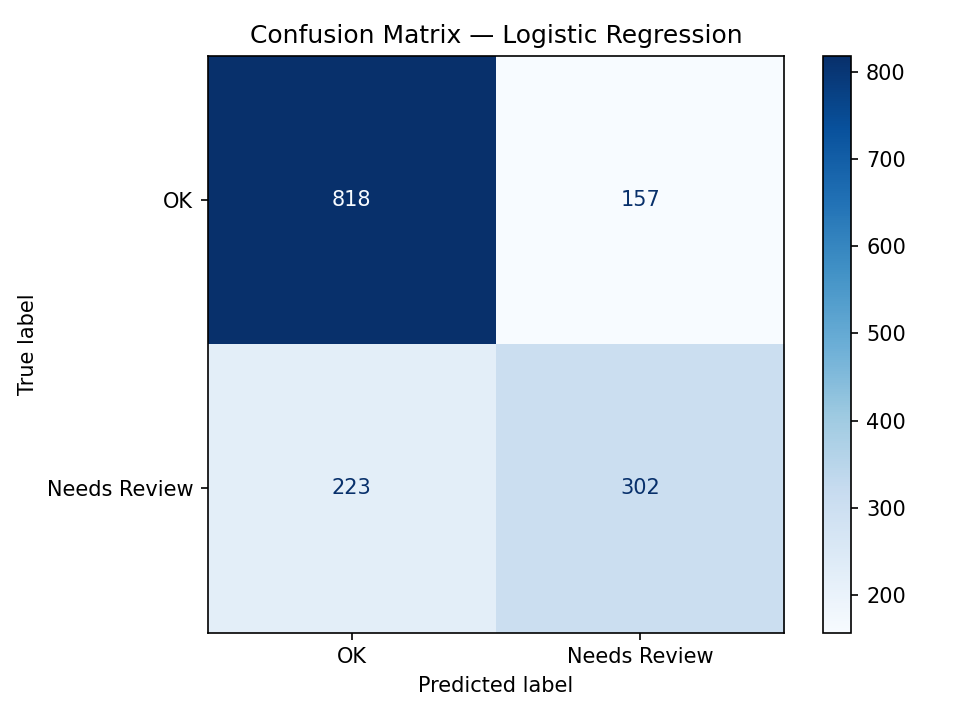

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['OK', 'Needs Review']).plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

## 10. Conclusions & business takeaway

- A simple, interpretable logistic regression model can flag ~58% of true review-needed
  timesheets (recall) while keeping precision around 0.66 — meaningfully concentrating manual
  review effort on the visits most likely to have an issue, rather than reviewing everything.
- The strongest signals are **operational, not demographic**: task completion, signatures, and
  GPS/location consistency — all things captured automatically at the point of data entry.
- Next steps for a production version: calibrate the decision threshold against the real cost
  of a missed review vs. an unnecessary one, and monitor for drift as caregiver onboarding and
  app adoption change over time.

An interactive version of this model (re-implemented from the exported coefficients) is
available as a small web dashboard in this repo — see `dashboard/`.